In [12]:
%load_ext autoreload
%autoreload 2

%aimport -faiss
%aimport -PIL

import sys
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

notebook_dir = Path().resolve()
project_root = notebook_dir.parent
src_path = str(project_root / "src")

if src_path not in sys.path:
    sys.path.append(src_path)

from hep_tracking.ann_models import FaissIVFFlat, FaissIVFPQ, HnswGraph
from hep_tracking.utils import calculate_recall

print("Zależności ANN załadowane pomyślnie!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Zależności ANN załadowane pomyślnie!


In [17]:
import numpy as np

# Wczytujemy oryginalne dane 5D
features_5d = np.load(data_path)["X"]

# Dodajemy dopełnienie (padding): 0 kolumn z lewej strony, 3 kolumny z prawej
# mode='constant' domyślnie wypełnia nowe wartości zerami
features_8d = np.pad(features_5d, ((0, 0), (0, 3)), mode='constant')

# Upewniamy się, że tablica jest C-contiguous i ma typ float32 wymagany przez FAISS
features = np.ascontiguousarray(features_8d, dtype=np.float32)

print(f"Oryginalne dane: {features_5d.shape}")
print(f"Dane z dopełnieniem zerami (dla FAISS GPU): {features.shape}")

Oryginalne dane: (99995, 5)
Dane z dopełnieniem zerami (dla FAISS GPU): (99995, 8)


In [14]:
def evaluate_ann_model(model_name, model_instance, features, true_indices, k):
    """Buduje indeks, wykonuje zapytanie i zwraca metryki (QPS, Recall)."""
    print(f"Trenowanie i budowa indeksu: {model_name}...")
    
    model_instance.build(features)
    
    start_time = time.perf_counter()
    _, pred_indices = model_instance.query(features, k)
    query_time = time.perf_counter() - start_time
    
    qps = features.shape[0] / query_time
    recall = calculate_recall(true_indices, pred_indices)
    
    print(f" -> QPS: {qps:,.0f} | Recall: {recall:.4f}\n")
    return qps, recall

In [18]:
import gc
import numpy as np

# 1. ŚCISŁA KONTROLA FORMATU DANYCH
# Zapobiega natychmiastowym awariom bibliotek hnswlib i FAISS
features = np.ascontiguousarray(features, dtype=np.float32)

USE_GPU = True

results = {
    "IVFFlat": {"recall": [], "qps": [], "labels": []},
    "IVFPQ": {"recall": [], "qps": [], "labels": []},
    "HNSW": {"recall": [], "qps": [], "labels": []}
}

nlist = 100

print("=== START IVFFlat ===")
for nprobe in [1, 2, 5, 10, 20, 50]:
    print(f" -> Inicjalizacja IVFFlat (nprobe={nprobe})...")
    model = FaissIVFFlat(nlist=nlist, nprobe=nprobe, use_gpu=USE_GPU)
    qps, recall = evaluate_ann_model(f"IVFFlat (nprobe={nprobe})", model, features, true_indices, k_neighbors)
    results["IVFFlat"]["qps"].append(qps)
    results["IVFFlat"]["recall"].append(recall)
    results["IVFFlat"]["labels"].append(f"np={nprobe}")
    
    # Wymuszone zwolnienie pamięci karty graficznej
    del model
    gc.collect()

print("\n=== START IVFPQ ===")
for nprobe in [1, 2, 5, 10, 20, 50, 100]:
    print(f" -> Inicjalizacja IVFPQ (nprobe={nprobe})...")
    model = FaissIVFPQ(nlist=nlist, m=4, nprobe=nprobe, use_gpu=False)
    qps, recall = evaluate_ann_model(f"IVFPQ (nprobe={nprobe})", model, features, true_indices, k_neighbors)
    results["IVFPQ"]["qps"].append(qps)
    results["IVFPQ"]["recall"].append(recall)
    results["IVFPQ"]["labels"].append(f"np={nprobe}")
    
    del model
    gc.collect()

print("\n=== START HNSW ===")
m_graph = 16
for ef in [10, 20, 50, 100, 200]:
    print(f" -> Inicjalizacja HNSW (ef={ef})...")
    model = HnswGraph(m=m_graph, ef_construction=200, ef=ef)
    qps, recall = evaluate_ann_model(f"HNSW (ef={ef})", model, features, true_indices, k_neighbors)
    results["HNSW"]["qps"].append(qps)
    results["HNSW"]["recall"].append(recall)
    results["HNSW"]["labels"].append(f"ef={ef}")
    
    del model
    gc.collect()

print("\nCAŁY BENCHMARK ZOSTAŁ POMYŚLNIE ZAKOŃCZONY!")

=== START IVFFlat ===
 -> Inicjalizacja IVFFlat (nprobe=1)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=1)...
 -> QPS: 12,411,059 | Recall: 0.8321

 -> Inicjalizacja IVFFlat (nprobe=2)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=2)...
 -> QPS: 8,771,348 | Recall: 0.9615

 -> Inicjalizacja IVFFlat (nprobe=5)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=5)...
 -> QPS: 4,383,006 | Recall: 0.9978

 -> Inicjalizacja IVFFlat (nprobe=10)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=10)...
 -> QPS: 2,366,512 | Recall: 0.9996

 -> Inicjalizacja IVFFlat (nprobe=20)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=20)...
 -> QPS: 1,206,359 | Recall: 1.0000

 -> Inicjalizacja IVFFlat (nprobe=50)...
Trenowanie i budowa indeksu: IVFFlat (nprobe=50)...
 -> QPS: 495,108 | Recall: 1.0000


=== START IVFPQ ===
 -> Inicjalizacja IVFPQ (nprobe=1)...
Trenowanie i budowa indeksu: IVFPQ (nprobe=1)...
 -> QPS: 290,838 | Recall: 0.7049

 -> Inicjalizacja IVFPQ (nprobe=2)...
Trenowanie i budowa inde

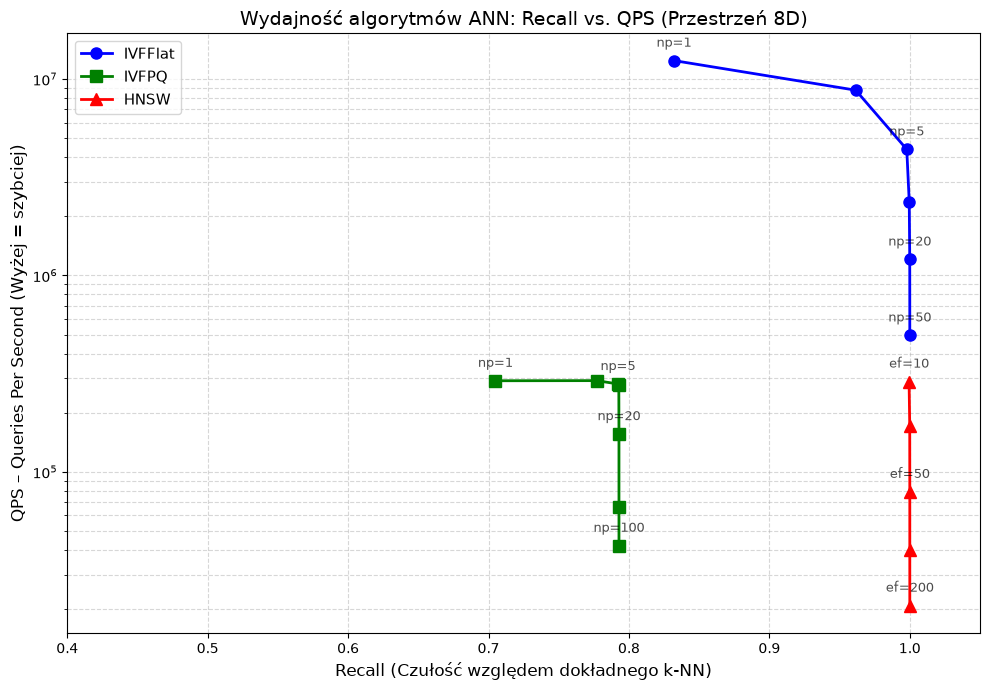

In [19]:
plt.figure(figsize=(10, 7))

colors = {"IVFFlat": "blue", "IVFPQ": "green", "HNSW": "red"}
markers = {"IVFFlat": "o", "IVFPQ": "s", "HNSW": "^"}

for name, data in results.items():
    plt.plot(data["recall"], data["qps"], 
             marker=markers[name], color=colors[name], 
             linestyle='-', linewidth=2, markersize=8, label=name)
    
    for i, label in enumerate(data["labels"]):
        if i % 2 == 0 or i == len(data["labels"]) - 1:
            plt.annotate(label, (data["recall"][i], data["qps"][i]), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, alpha=0.7)

plt.yscale("log")
plt.xlabel("Recall (Czułość względem dokładnego k-NN)", fontsize=12)
plt.ylabel("QPS – Queries Per Second (Wyżej = szybciej)", fontsize=12)

# Zaktualizowano tytuł wykresu dla przestrzeni 8D
plt.title("Wydajność algorytmów ANN: Recall vs. QPS (Przestrzeń 8D)", fontsize=14)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)

# Rozszerzamy zakres osi X, aby lepiej uwidocznić niższe wartości recall
plt.xlim(0.4, 1.05)

plt.tight_layout()
plt.show()